# 🇧🇭 Bahraini Food AI — Dataset, Training & Evaluation

This notebook documents the Bahraini food image-classification workflow used for the deployed Streamlit application. The current dataset contains 8 food classes and 240 images. The notebook is organized around the project workflow and keeps all Python imports in one cell at the top.

In [2]:
!pip install -q ultralytics pyyaml seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.9/63.9 kB 6.4 MB/s eta 0:00:00


In [3]:
import os
import random
import shutil
import zipfile
import json
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from google.colab import drive
from google.colab import files
from ultralytics import YOLO
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [1]:
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
zip_path = "/content/drive/MyDrive/food.zip"
extract_path = "/content/food"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print(os.listdir(extract_path))

['food', '__MACOSX']


In [7]:
food_path = "/content/food/food"

print("Classes:")
print(os.listdir(food_path))

Classes:
['luqemat', 'raqaq', 'balalet', 'makboos', 'teka', '.DS_Store', 'halwa', 'karak', 'sambosa']


In [8]:
valid_extensions = (".jpg", ".jpeg", ".png", ".webp")

total = 0

for cls in sorted(os.listdir(food_path)):
    folder = os.path.join(food_path, cls)

    if not os.path.isdir(folder):
        continue

    images = [f for f in os.listdir(folder)if f.lower().endswith(valid_extensions)]

    print(f"{cls}: {len(images)} images")
    total += len(images)

print("\nTotal images:", total)

balalet: 30 images
halwa: 30 images
karak: 30 images
luqemat: 30 images
makboos: 30 images
raqaq: 30 images
sambosa: 30 images
teka: 30 images

Total images: 240


In [9]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 36.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.9/63.9 kB 7.2 MB/s eta 0:00:00


In [10]:
food_path = "/content/food/food"
dataset_path = "/content/bahraini_food_dataset"

classes = [
    "balalet",
    "halwa",
    "karak",
    "luqemat",
    "makboos",
    "raqaq",
    "sambosa",
    "teka"]

class_to_id = {name: i for i, name in enumerate(classes)}

print(class_to_id)

{'balalet': 0, 'halwa': 1, 'karak': 2, 'luqemat': 3, 'makboos': 4, 'raqaq': 5, 'sambosa': 6, 'teka': 7}


In [11]:
for split in ["train", "val", "test"]:
    os.makedirs(f"{dataset_path}/images/{split}", exist_ok=True)
    os.makedirs(f"{dataset_path}/labels/{split}", exist_ok=True)

print("Dataset folders created.")

Dataset folders created.


In [12]:
random.seed(42)

for cls in classes:

    source_folder = os.path.join(food_path, cls)

    images = [f for f in os.listdir(source_folder)if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))]

    random.shuffle(images)

    n = len(images)

    train_end = int(n * 0.70)
    val_end = train_end + int(n * 0.20)

    train_images = images[:train_end]
    val_images = images[train_end:val_end]
    test_images = images[val_end:]

    splits = {"train": train_images,"val": val_images,"test": test_images}

    for split, split_images in splits.items():

        for image_name in split_images:

            source = os.path.join(source_folder, image_name)
            destination = os.path.join(dataset_path,"images",split,f"{cls}_{image_name}")

            shutil.copy2(source, destination)

    print(
        f"{cls}: "
        f"Train={len(train_images)}, "
        f"Val={len(val_images)}, "
        f"Test={len(test_images)}"
    )

balalet: Train=21, Val=6, Test=3
halwa: Train=21, Val=6, Test=3
karak: Train=21, Val=6, Test=3
luqemat: Train=21, Val=6, Test=3
makboos: Train=21, Val=6, Test=3
raqaq: Train=21, Val=6, Test=3
sambosa: Train=21, Val=6, Test=3
teka: Train=21, Val=6, Test=3


In [13]:
for split in ["train", "val", "test"]:

    folder = f"{dataset_path}/images/{split}"

    count = len([f for f in os.listdir(folder)if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))])

    print(f"{split}: {count} images")

train: 168 images
val: 48 images
test: 24 images


In [14]:
data = {
    "path": dataset_path,
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "names": classes
}

yaml_path = os.path.join(dataset_path, "data.yaml")

with open(yaml_path, "w") as f:
    yaml.dump(data, f, sort_keys=False)

print("data.yaml created:")
print(yaml_path)

with open(yaml_path, "r") as f:
    print(f.read())

data.yaml created:
/content/bahraini_food_dataset/data.yaml
path: /content/bahraini_food_dataset
train: images/train
val: images/val
test: images/test
names:
- balalet
- halwa
- karak
- luqemat
- makboos
- raqaq
- sambosa
- teka



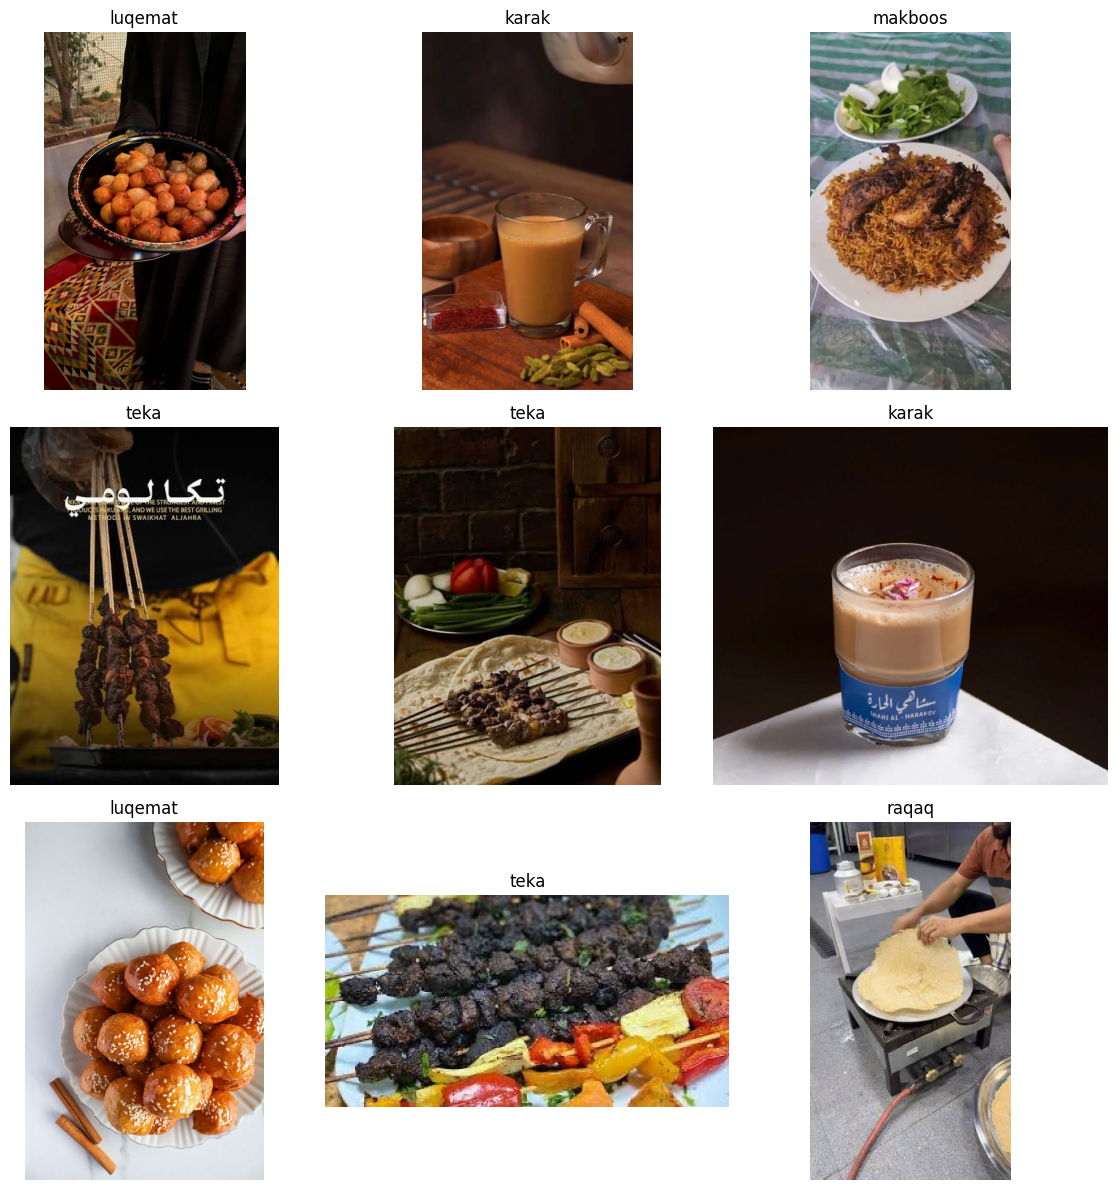

In [15]:
train_path = f"{dataset_path}/images/train"

image_files = [f for f in os.listdir(train_path)if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))]

sample_images = random.sample(image_files, min(9, len(image_files)))

plt.figure(figsize=(12, 12))

for i, image_name in enumerate(sample_images):
    image = Image.open(os.path.join(train_path, image_name))

    plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(image_name.split("_")[0])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [16]:
food_path = "/content/food/food"

classes = [
    "balalet",
    "halwa",
    "karak",
    "luqemat",
    "makboos",
    "raqaq",
    "sambosa",
    "teka"
]

for cls in classes:
    folder = os.path.join(food_path, cls)

    images = [
        f for f in os.listdir(folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))
    ]

    print(f"{cls}: {len(images)}")

balalet: 30
halwa: 30
karak: 30
luqemat: 30
makboos: 30
raqaq: 30
sambosa: 30
teka: 30


In [17]:
source = "/content/bahraini_food_dataset/images"
zip_file = "/content/bahraini_food_images"

shutil.make_archive(zip_file, "zip", source)

print("ZIP created:")
print("/content/bahraini_food_images.zip")

ZIP created:
/content/bahraini_food_images.zip


In [18]:
from google.colab import files

files.download("/content/bahraini_food_images.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [20]:
source_dataset = "/content/bahraini_food_dataset"
classification_dataset = "/content/bahraini_food_classification"

classes = [
    "balalet",
    "halwa",
    "karak",
    "luqemat",
    "makboos",
    "raqaQ",
    "sambosa",
    "teka"
]

for split in ["train", "val", "test"]:
    for cls in classes:
        os.makedirs(
            os.path.join(classification_dataset, split, cls),
            exist_ok=True
        )

for split in ["train", "val", "test"]:

    source_folder = os.path.join(source_dataset, "images", split)

    for filename in os.listdir(source_folder):

        if not filename.lower().endswith((".jpg", ".jpeg", ".png", ".webp")):
            continue

        class_name = filename.split("_")[0].lower()

        if class_name == "raqaq":
            class_name = "raqaQ".lower()

        if class_name not in [c.lower() for c in classes]:
            print("Unknown class:", filename)
            continue

        destination_class = next(c for c in classes if c.lower() == class_name)

        source = os.path.join(source_folder, filename)

        destination = os.path.join(classification_dataset,split,destination_class,filename)

        shutil.copy2(source, destination)

print("Classification dataset created!")

Classification dataset created!


In [21]:
for split in ["train", "val", "test"]:

    print(f"\n{split.upper()}")

    for cls in classes:

        folder = os.path.join(classification_dataset,split,cls)

        count = len([f for f in os.listdir(folder)if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))])

        print(f"{cls}: {count}")


TRAIN
balalet: 21
halwa: 21
karak: 21
luqemat: 21
makboos: 21
raqaQ: 21
sambosa: 21
teka: 21

VAL
balalet: 6
halwa: 6
karak: 6
luqemat: 6
makboos: 6
raqaQ: 6
sambosa: 6
teka: 6

TEST
balalet: 3
halwa: 3
karak: 3
luqemat: 3
makboos: 3
raqaQ: 3
sambosa: 3
teka: 3


In [22]:
model = YOLO("yolo11n-cls.pt")

results = model.train(data=classification_dataset,epochs=30,imgsz=224,batch=16,patience=8,project="/content/runs",name="bahraini_food_classifier")

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.120 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/bahraini_food_classification, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipu

In [24]:
best_model = YOLO("/content/runs/bahraini_food_classifier/weights/best.pt")

print("Model loaded successfully!")

Model loaded successfully!


In [25]:
test_image = "/content/bahraini_food_classification/test/balalet"

image_name = os.listdir(test_image)[0]

image_path = os.path.join(test_image, image_name)

results = best_model(image_path)

probs = results[0].probs

predicted_class = results[0].names[probs.top1]
confidence = float(probs.top1conf)

print("Predicted:", predicted_class)
print("Confidence:", confidence)


image 1/1 /content/bahraini_food_classification/test/balalet/balalet_04c2c873-0a5e-403a-af44-796f9c407a43.JPG: 224x224 balalet 1.00, teka 0.00, halwa 0.00, makboos 0.00, raqaQ 0.00, 5.9ms
Speed: 28.2ms preprocess, 5.9ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)
Predicted: balalet
Confidence: 0.9999674558639526


In [26]:
y_true = []
y_pred = []

test_path = "/content/bahraini_food_classification/test"

for class_name in classes:

    class_folder = os.path.join(test_path, class_name)

    for image_name in os.listdir(class_folder):

        if not image_name.lower().endswith((".jpg", ".jpeg", ".png", ".webp")):
            continue

        image_path = os.path.join(class_folder, image_name)

        results = best_model(image_path, verbose=False)

        predicted_id = results[0].probs.top1
        predicted_class = results[0].names[predicted_id]

        y_true.append(class_name)
        y_pred.append(predicted_class)

print("Total test images:", len(y_true))

Total test images: 24


In [27]:
print(classification_report(y_true,y_pred,labels=classes,zero_division=0))

              precision    recall  f1-score   support

     balalet       1.00      1.00      1.00         3
       halwa       1.00      1.00      1.00         3
       karak       1.00      1.00      1.00         3
     luqemat       1.00      1.00      1.00         3
     makboos       1.00      1.00      1.00         3
       raqaQ       1.00      1.00      1.00         3
     sambosa       1.00      1.00      1.00         3
        teka       1.00      1.00      1.00         3

    accuracy                           1.00        24
   macro avg       1.00      1.00      1.00        24
weighted avg       1.00      1.00      1.00        24



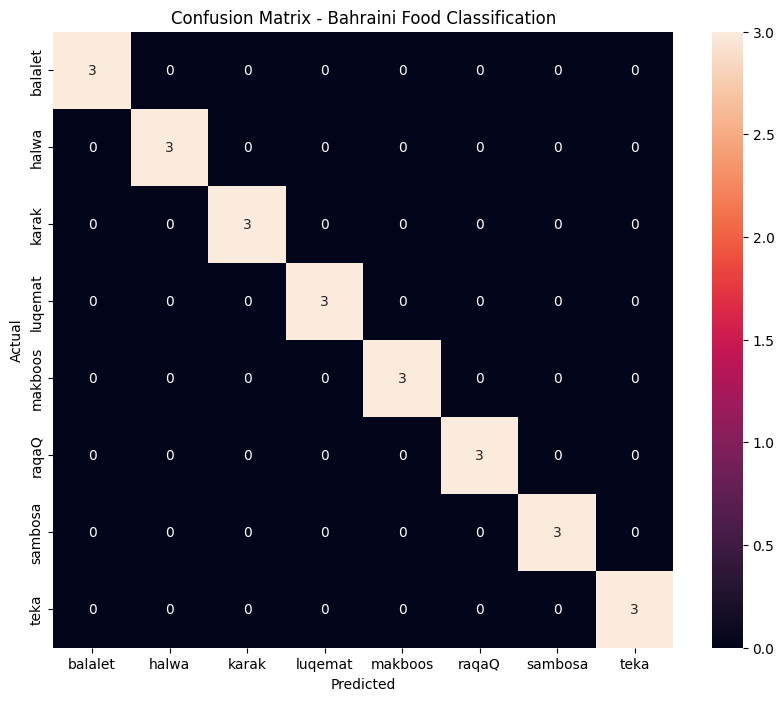

In [28]:
cm = confusion_matrix(y_true,y_pred,labels=classes)

plt.figure(figsize=(10, 8))

sns.heatmap(cm,annot=True,fmt="d",xticklabels=classes,yticklabels=classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Bahraini Food Classification")
plt.show()

In [29]:
source = "/content/runs/bahraini_food_classifier/weights/best.pt"
destination = "/content/bahraini_food_model.pt"

shutil.copy(source, destination)

print("Model saved:", destination)
print("File size:", round(os.path.getsize(destination) / (1024 * 1024), 2), "MB")

Model saved: /content/bahraini_food_model.pt
File size: 3.05 MB


In [30]:
val_results = best_model.val(data="/content/bahraini_food_classification",split="val")

print(val_results)

Ultralytics 8.4.120 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
train: /content/bahraini_food_classification/train... found 168 images in 8 classes ✅ 
val: /content/bahraini_food_classification/val... found 48 images in 8 classes ✅ 
test: /content/bahraini_food_classification/test... found 24 images in 8 classes ✅ 
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2026.7±577.5 MB/s, size: 100.1 KB)
val: Scanning /content/bahraini_food_classification/val... 48 images, 0 corrupt: 100% ━━━━━━━━━━━━ 48/48 20.1Mit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 3/3 1.3it/s 2.3s
                   all      0.958          1
Speed: 0.7ms preprocess, 5.4ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/runs/classify/val
ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d1f11ce6720>
curves: []
curves_results: []
fitness: 0.97916665673

In [31]:
test_path = "/content/bahraini_food_classification/test"

for class_name in classes:

    folder = os.path.join(test_path, class_name)

    images = [
        f for f in os.listdir(folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))
    ]

    image_name = random.choice(images)
    image_path = os.path.join(folder, image_name)

    results = best_model(image_path, verbose=False)

    predicted_id = results[0].probs.top1
    predicted_class = results[0].names[predicted_id]
    confidence = float(results[0].probs.top1conf)

    print(
        f"Actual: {class_name:8} | "
        f"Predicted: {predicted_class:8} | "
        f"Confidence: {confidence:.3f}"
    )

Actual: balalet  | Predicted: balalet  | Confidence: 1.000
Actual: halwa    | Predicted: halwa    | Confidence: 0.891
Actual: karak    | Predicted: karak    | Confidence: 0.999
Actual: luqemat  | Predicted: luqemat  | Confidence: 0.845
Actual: makboos  | Predicted: makboos  | Confidence: 0.995
Actual: raqaQ    | Predicted: raqaQ    | Confidence: 0.814
Actual: sambosa  | Predicted: sambosa  | Confidence: 1.000
Actual: teka     | Predicted: teka     | Confidence: 0.954


In [32]:
class_names = best_model.names

print(class_names)

with open("/content/class_names.json", "w") as f:
    json.dump(class_names, f)

print("class_names.json saved!")

{0: 'balalet', 1: 'halwa', 2: 'karak', 3: 'luqemat', 4: 'makboos', 5: 'raqaQ', 6: 'sambosa', 7: 'teka'}
class_names.json saved!


In [33]:
files.download("/content/bahraini_food_model.pt")
files.download("/content/class_names.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Project Requirements Check & Next Steps

The current implementation is an **image classification** system, not a bounding-box object detector. The supplied lab requires 10 food classes, at least 300 original images, YOLO bounding-box annotations, an unseen test set, error analysis, and a targeted second-round dataset. The current notebook has 8 classes and 240 images, so those missing requirements should be completed if the submission is being graded strictly against the lab brief. The current classifier is nevertheless suitable for the deployed Streamlit app because it predicts one food class for an uploaded image.